In [70]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
with open("/home/silver/Desktop/Projects/ML-Algos/Datasets/names.txt", "r") as file:
    content = file.read()
    words = content.splitlines()

In [72]:
print(f"Total number of names: {len(words)}")

Total number of names: 32033


In [73]:
print(f"Length of smallest name: {min(len(w) for w in words)}")

Length of smallest name: 2


In [74]:
print(f"Length of smallest name: {max(len(w) for w in words)}")

Length of smallest name: 15


In [75]:
stoi = {s:i+1 for i, s in enumerate(sorted(list(set("".join(words)))))}
stoi ["."] = 0
itos = {i:s for s,i in stoi.items()}

In [76]:
count_tensor = torch.zeros((27, 27), dtype=torch.int32)

In [77]:
bigrams = {}
for word in words:
    word = ["."] + list(word) + ["."]
    for f, l in zip(word, word[1:]):
        ix1 = stoi[f]
        ix2 = stoi[l]
        count_tensor[ix1, ix2] += 1

#### Heatmap of Occurance of Char-level Bigram

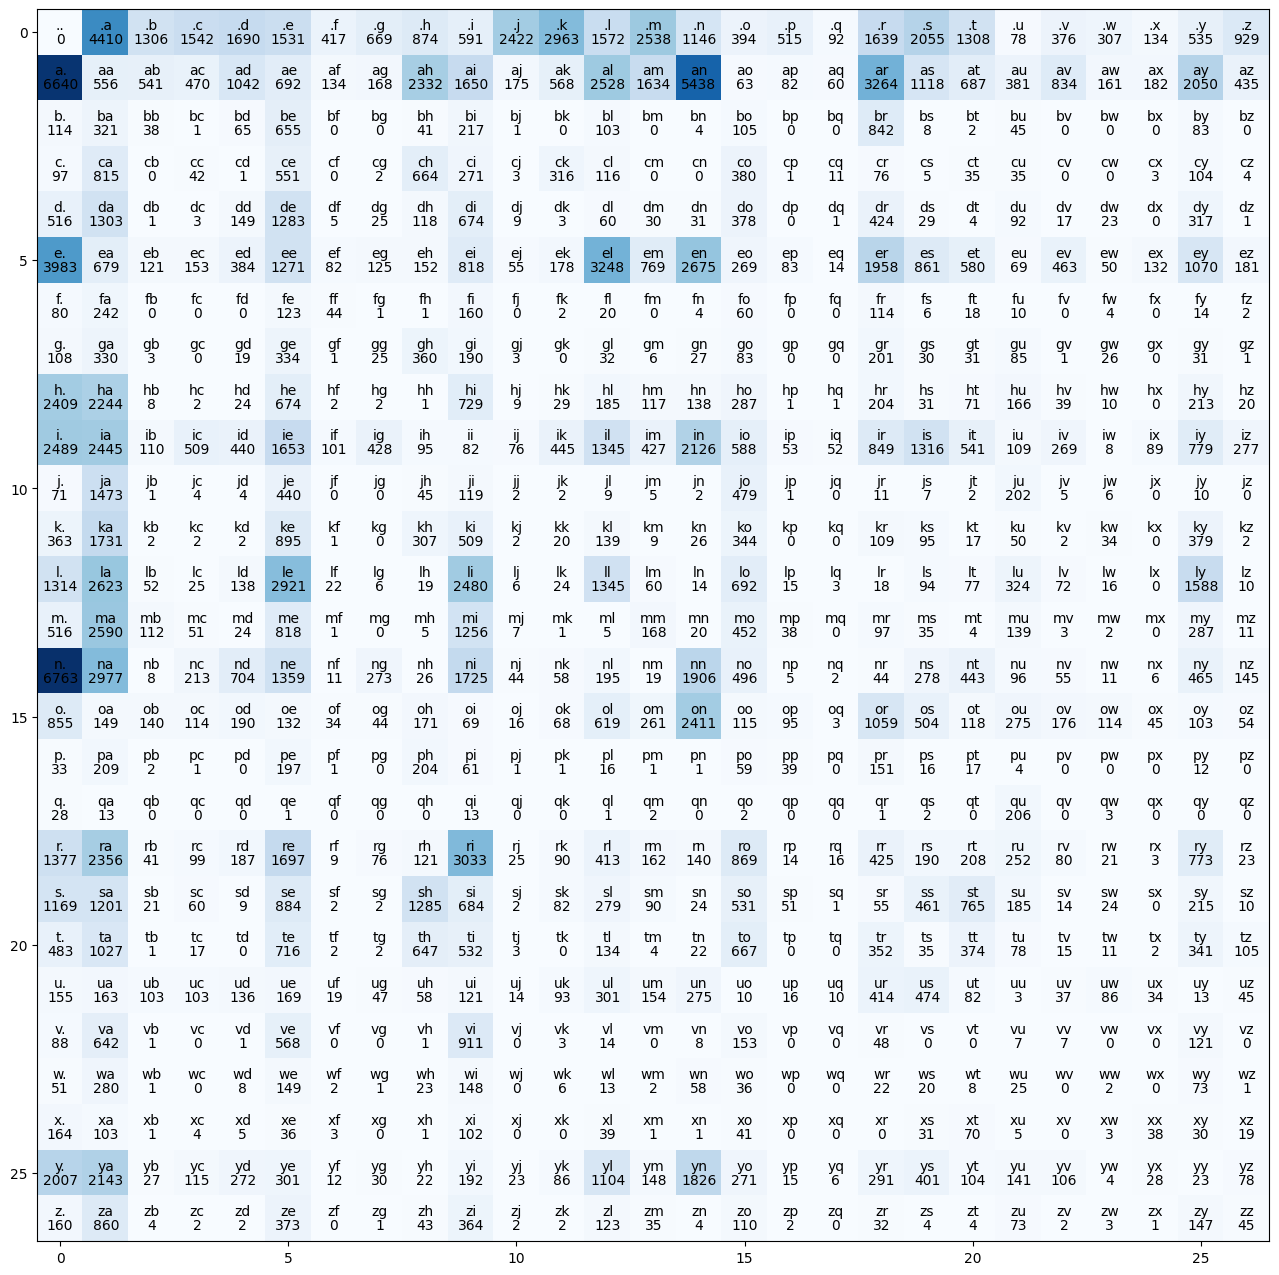

In [ ]:
plt.figure(figsize=(16,16))
cax = plt.imshow(count_tensor, cmap="Blues")

for i in range(27):
    for j in range(27):
        plt.text(j, i, f"{itos[i]+itos[j]}", va="bottom", ha="center")
        plt.text(j, i, count_tensor[i, j].item(), va="top", ha="center")
        
plt.show()

In [150]:
prob_tensor = (count_tensor+1).float()                      # Adding 1 to each value because we will take log of prob and it will result in infinity. 
prob_tensor = prob_tensor/prob_tensor.sum(1, keepdim=True)

In [135]:
g = torch.Generator().manual_seed(1234)
for i in range(10):
    out = ""
    ix = 0
    while True:
        p = prob_tensor[ix]

        # p = torch.ones(27)/27

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix==0:
            break
        
        out += itos[ix]
    print(out)

kyason
kanana
milaveela
ra
drisan
lurtolisyrsh
tobay
n
myeeahare
chucinailelulelone


## Loss Function

### Using Average Negative Log-Likelihood (NLL) as the Loss Function

- The **likelihood** of the training data is the product of the predicted probabilities for all correct outcomes. Since probabilities are between 0 and 1, their product becomes extremely small, making it numerically unstable to work with directly.
- Taking the **logarithm** of the likelihood converts the product into a sum, improving numerical stability. The resulting **log-likelihood** always lies in the range **(-∞, 0]**, where values closer to **0** indicate better model performance.
- However, optimization algorithms are typically designed to **minimize** a loss function. Since a **higher log-likelihood** corresponds to a better model, it is not suitable to use directly as the loss.
- Therefore, we use the **negative log-likelihood (NLL)**, which reverses the objective: better predictions produce a smaller loss.
- Finally, we compute the **average negative log-likelihood** over all training examples, making the loss independent of the dataset size and suitable for optimization using gradient-based methods.

In [153]:
log_likelihood = 0
count = 0
for word in words[:3]:
    word = ["."] + list(word) + ["."]
    for f, l in zip(word, word[1:]):
        ix1 = stoi[f]
        ix2 = stoi[l]
        prob = prob_tensor[ix1, ix2]
        log_prob = torch.log(prob)
        log_likelihood += log_prob
        count+=1

print(f"{log_likelihood=: 0.4f}")
print(f"loss function: {-log_likelihood/count: 0.4f}")

log_likelihood=-38.8086
loss function:  2.4255
